In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run: pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
sns.set_style("darkgrid")

In [4]:
print('xgcm version', xgcm.__version__, '\nregionate version', regionate.__version__, '\nxwmt version', xwmt.__version__, '\nxwmb version', xwmb.__version__)

xgcm version 0.8.2.dev52+g5398098 
regionate version 0.3.3 
xwmt version 0.1.0 
xwmb version 0.3.0


In [5]:
import xarray as xr
import numpy as np

In [7]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x
ds_coords = xr.open_mfdataset(
        datadir("model/budgets_sigma2_1p5/CM4Xp125_budgets_sigma2_1885-1889.zarr"),
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")

In [8]:
coords={
    'X': {k:v for (k,v) in {'center':'xh','outer':'xq'}.items()
          if v in ds_coords},
    'Y': {k:v for (k,v) in {'center':'yh','outer':'yq'}.items()
          if v in ds_coords},
}
metrics = {
        ('X','Y'): "areacello",
    }

boundary = {"X":"periodic", "Y":"extend", "Z":"extend"}

grid = Grid(
    ds_coords,
    coords=coords,
    metrics=metrics,
    boundary=boundary,
    autoparse_metadata=False
)

In [9]:
def dll_dist(dlon, dlat, lon_lat, lat):
    """
    Convert lat/lon differences (degrees) into distances (meters)
    
    Parameters
    ----------
    dlon : xarray.DataArray
        Longitude differences in degrees
    dlat : xarray.DataArray
        Latitude differences in degrees
    lat : xarray.DataArray
        Latitude at the location of the difference (degrees)
        
    Returns
    -------
    dx : xarray.DataArray
        Distance in meters along longitude
    dy : xarray.DataArray
        Distance in meters along latitude
    """
    distance_1deg = 111000.0  # meters per degree (approx)
    
    dx = dlon * np.cos(np.deg2rad(lon_lat)) * distance_1deg
    dy = dlat * distance_1deg
    
    return dx, dy

    
dlatc = grid.diff(ds_coords["geolat"], 'Y', boundary='fill', fill_value=np.nan) #distance between cell centers
dlonc = grid.diff(ds_coords["geolon"], 'X', boundary='fill', fill_value=np.nan) #distance between cell centers

dlong = grid.diff(ds_coords["geolon_u"], 'X', boundary='fill', fill_value=np.nan) #distance between cell centers
dlatg = grid.diff(ds_coords["geolat_v"], 'Y', boundary='fill', fill_value=np.nan) #distance between cell centers

ds_coords.coords['dxg'], ds_coords.coords['dyg'] = dll_dist(dlong, dlatg, grid._ds.geolat, grid._ds.geolat)
ds_coords.coords['dxc'], ds_coords.coords['dyc'] = dll_dist(dlonc, dlatc, grid._ds.geolat_u, grid._ds.geolat_v)


In [19]:
dtau_y_dx = grid.interp(ds_coords['tauy'].where(ds_coords.wet > 0.0) , 'X', boundary='extend') #interpolate to midpoints
dtau_y_dx = grid.diff(dtau_y_dx, 'X', boundary='extend') / ds_coords.coords['dxg'] #take diff divide by distance, this step is equivalent to a second order 
# # / 
dtau_x_dy = grid.interp(ds_coords['taux'].where(ds_coords.wet > 0.0), 'Y', boundary='extend')
dtau_x_dy = grid.diff(dtau_x_dy, 'Y', boundary='extend') / ds_coords.coords['dyg']


wstress_curl = (dtau_y_dx - dtau_x_dy)

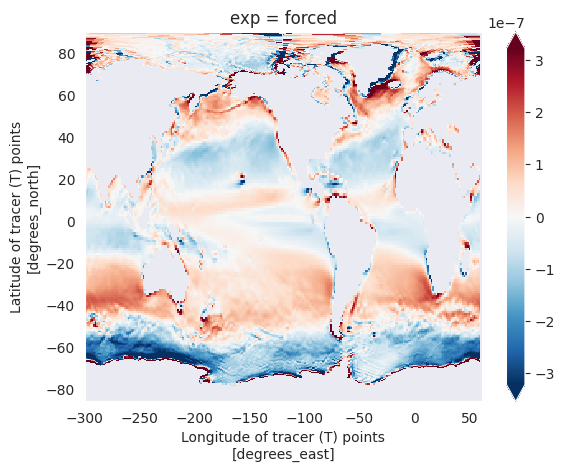

In [20]:
wstress_curl.isel(exp = 0).mean("time").plot(x = "geolon", y = "geolat", robust = True)

In [38]:
f = 2 *  7.2921e-5 * np.sin(np.deg2rad(ds_coords.geolat))
f = f.where(np.abs(ds_coords.geolat) > 5.0)

In [39]:
dtau_y_dx = grid.interp(ds_coords['tauy'].where(ds_coords.wet > 0.0) / f , 'X', boundary='extend') #interpolate to midpoints
dtau_y_dx = grid.diff(dtau_y_dx, 'X', boundary='extend') / ds_coords.coords['dxg'] #take diff divide by distance, this step is equivalent to a second order 
# # / 
dtau_x_dy = grid.interp(ds_coords['taux'].where(ds_coords.wet > 0.0) / f, 'Y', boundary='extend')
dtau_x_dy = grid.diff(dtau_x_dy, 'Y', boundary='extend') / ds_coords.coords['dyg']


ekpump = (dtau_y_dx - dtau_x_dy)  / 1035. 

ekpump = ekpump * 3.154e+7 #convert to meters per year

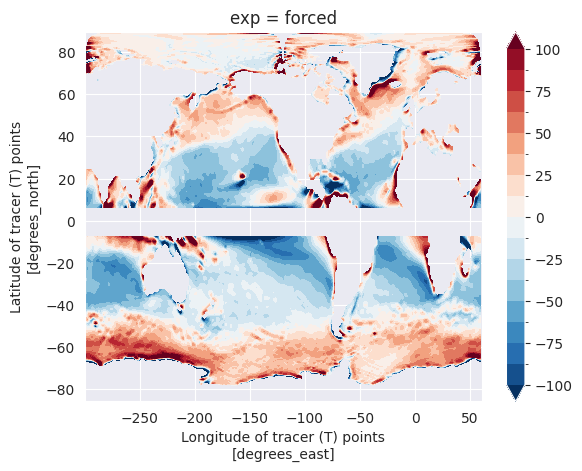

In [41]:
levels = np.arange(-100, 101, 12.5)
ekpump.sel(exp = "forced").mean("time").plot.contourf(x = "geolon", y = "geolat", levels = levels)

